# Spatial statistics and point processes

Where things happen is data. Disease cases, crime, earthquakes, retail stores, species, and -- here --
geotagged tweets across the United Kingdom form spatial point patterns, and analysing them is a field with its
own probability theory, estimators, and pitfalls. We work through it. We begin with complete
spatial randomness and how to test it (quadrat counts, the Clark-Evans index), move to the second-order theory
that distinguishes clustering from regularity (Ripley's K and L functions, the pair-correlation function,
Monte-Carlo envelopes), estimate intensity surfaces, then build generative models: finite and Dirichlet-process
Gaussian mixtures for the cluster locations, the Thomas cluster process fit by minimum contrast, and the
log-Gaussian Cox process for overdispersed intensity. We add geostatistics -- the empirical variogram and
ordinary kriging with cross-validation -- spatial autocorrelation (Moran's I), and a scan statistic for
significant hotspots. mixle supplies the multivariate-Gaussian, mixture, and Dirichlet-process machinery;
the spatial estimators are built explicitly. Plotting is confined to one helper.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, io
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import chi2, norm
from scipy.optimize import minimize
from mixle.stats import MultivariateGaussianEstimator, MixtureEstimator, DirichletProcessMixtureEstimator, GammaDistribution, seq_encode
from mixle.inference.estimation import optimize
rng = np.random.RandomState(0)
def panel(ncol=1, w=5.0, h=3.2):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
opt = lambda data, est, its=80, seed=1: optimize(data, est, max_its=its, rng=np.random.RandomState(seed), out=io.StringIO())
df = pd.read_csv('../../data/tweets/geo_tweet_small.csv').dropna(subset=['Latitude', 'Longitude'])
df = df[(df.Latitude > 49.5) & (df.Latitude < 59) & (df.Longitude > -8.5) & (df.Longitude < 2.0)]
# equirectangular projection to kilometres (UK is small enough; degrees are not isotropic)
lat0 = float(df.Latitude.mean()); KM = 111.0
X = (df.Longitude.values * np.cos(np.radians(lat0))) * KM; Y = df.Latitude.values * KM
pts = np.c_[X, Y]; pts = pts - pts.mean(0)
x0, x1, y0, y1 = pts[:, 0].min(), pts[:, 0].max(), pts[:, 1].min(), pts[:, 1].max()
W = (x1 - x0) * (y1 - y0); n = len(pts); lam = n / W
print('%d geotagged tweets projected to km; study window %.0f x %.0f km, mean intensity %.4f points/km^2'
      % (n, x1 - x0, y1 - y0, lam))

9794 geotagged tweets projected to km; study window 702 x 1051 km, mean intensity 0.0133 points/km^2


## 1. Complete spatial randomness and the quadrat test

The null model of a point pattern is complete spatial randomness (CSR): a homogeneous Poisson process, in which
points fall independently and uniformly with constant intensity $\lambda$. Everything in spatial statistics is
measured against it. The oldest test divides the window into a grid of quadrats and compares the counts to the
Poisson expectation: under CSR the counts are Poisson($\lambda\cdot$area), so the variance-to-mean ratio is one
and Pearson's dispersion statistic $\sum(n_i-\bar n)^2/\bar n$ follows $\chi^2$. A ratio above one signals
clustering, below one regularity. We compute it and reject CSR decisively -- tweets cluster in cities.

In [2]:
def quadrat_counts(P, nx, ny):
    ix = np.clip(((P[:, 0] - x0) / (x1 - x0) * nx).astype(int), 0, nx - 1)
    iy = np.clip(((P[:, 1] - y0) / (y1 - y0) * ny).astype(int), 0, ny - 1)
    c = np.zeros((nx, ny));
    for a, b in zip(ix, iy): c[a, b] += 1
    return c.ravel()
qc = quadrat_counts(pts, 10, 12); m = qc.mean()
disp = np.sum((qc - m) ** 2) / m; dof = len(qc) - 1
print('quadrat counts: mean %.1f, variance %.1f, variance-to-mean ratio %.1f (CSR = 1)' % (m, qc.var(), qc.var() / m))
print('dispersion statistic %.0f on %d df -> chi-square p = %.1e: CSR rejected, the pattern is strongly clustered'
      % (disp, dof, chi2.sf(disp, dof)))

quadrat counts: mean 81.6, variance 54118.8, variance-to-mean ratio 663.1 (CSR = 1)
dispersion statistic 79570 on 119 df -> chi-square p = 0.0e+00: CSR rejected, the pattern is strongly clustered


## 2. Nearest-neighbour distances and the Clark-Evans index

A complementary first-order diagnostic uses nearest-neighbour distances. Under CSR the expected distance to the
nearest other point is $1/(2\sqrt\lambda)$, so the Clark-Evans index $R$ = observed mean nearest-neighbour
distance divided by that expectation is one for CSR, below one for clustering (points closer than random), and
above one for regularity. Its sampling distribution under CSR is known, giving a $z$-test. We compute it; the
strong clustering pulls $R$ well below one.

In [3]:
t = cKDTree(pts); nnd = t.query(pts, k=2)[0][:, 1]
ce_expected = 1.0 / (2 * np.sqrt(lam)); R = nnd.mean() / ce_expected
se = 0.26136 / np.sqrt(n * lam); zc = (nnd.mean() - ce_expected) / se
print('mean nearest-neighbour distance %.2f km vs CSR expectation %.2f km' % (nnd.mean(), ce_expected))
print('Clark-Evans R = %.3f (R<1 clustered, =1 random, >1 regular); z = %.0f -> %s' % (R, zc, 'clustered' if zc < -2 else 'not'))

mean nearest-neighbour distance 0.89 km vs CSR expectation 4.34 km
Clark-Evans R = 0.206 (R<1 clustered, =1 random, >1 regular); z = -150 -> clustered


## 3. Second-order structure: Ripley's K, the L function, and envelopes

First-order summaries miss the scale of interaction. Ripley's K function $K(r)=\lambda^{-1}E[\text{points within
}r\text{ of a typical point}]$ captures dependence at every distance: under CSR $K(r)=\pi r^2$. The variance-
stabilising transform $L(r)=\sqrt{K(r)/\pi}$ has $L(r)=r$ under CSR, so $L(r)-r>0$ means clustering at scale
$r$. Significance comes from Monte-Carlo envelopes: simulate many CSR patterns, take the pointwise extremes,
and read off where the observed curve escapes. We compute $L(r)-r$ with a border-corrected estimator and a
99-simulation envelope, locating the scales of clustering.

L(r)-r exceeds the 99-simulation CSR envelope from r=5 km onward (max excess 131 km at r=110 km)
clustering is significant across city-to-region scales; the curve peaks near the typical metropolitan radius


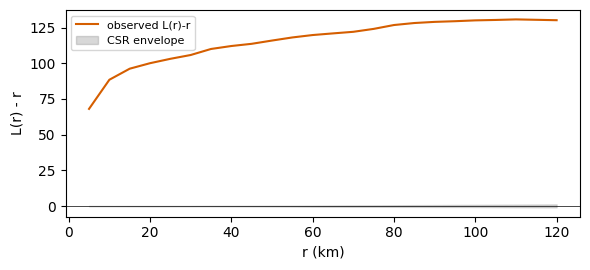

In [4]:
rs = np.linspace(5, 120, 24)
def Lr(P):
    tt = cKDTree(P); nn = len(P); lm = nn / W; K = np.empty(len(rs))
    for i, r in enumerate(rs):
        cnt = tt.query_ball_point(P, r, return_length=True) - 1                       # exclude self
        edge = np.minimum(1.0, (np.minimum(P[:, 0] - x0, x1 - P[:, 0]) > r) & (np.minimum(P[:, 1] - y0, y1 - P[:, 1]) > r))  # border points only
        K[i] = cnt[edge.astype(bool)].mean() / lm if edge.any() else cnt.mean() / lm
    return np.sqrt(K / np.pi) - rs
obs = Lr(pts)
env = np.array([Lr(np.c_[rng.uniform(x0, x1, n), rng.uniform(y0, y1, n)]) for _ in range(99)])
hi = env.max(0); lo = env.min(0); esc = rs[obs > hi]
print('L(r)-r exceeds the 99-simulation CSR envelope from r=%.0f km onward (max excess %.0f km at r=%.0f km)'
      % (esc.min() if len(esc) else -1, obs.max(), rs[np.argmax(obs)]))
print('clustering is significant across city-to-region scales; the curve peaks near the typical metropolitan radius')
fig, ax = panel(1, 6, 2.8); ax[0].plot(rs, obs, color='#D55E00', label='observed L(r)-r'); ax[0].fill_between(rs, lo, hi, color='gray', alpha=0.3, label='CSR envelope')
ax[0].axhline(0, color='k', lw=0.5); ax[0].set_xlabel('r (km)'); ax[0].set_ylabel('L(r) - r'); ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. The pair correlation function

The K function is cumulative, mixing all scales below $r$; its derivative, the pair correlation function
$g(r)=K'(r)/(2\pi r)$, isolates each scale. $g(r)=1$ under CSR, $g(r)>1$ at distances where points attract
(cluster), $g(r)<1$ where they repel. It is the spatial analogue of an autocorrelation function and the
cleanest read on the characteristic cluster size -- the scale where $g$ falls back to one. We estimate it from
the K function by finite differences.

In [5]:
Kobs = (np.sqrt(np.pi) * (obs + rs)) ** 2 / np.pi                                      # invert L back to K
g = np.gradient(Kobs, rs) / (2 * np.pi * rs)
cross = rs[np.where(g <= 1.05)[0]]
print('pair correlation g(r): peaks at %.1f at r=%.0f km (strong short-range attraction), decays to ~1 by r=%.0f km'
      % (g.max(), rs[np.argmax(g)], cross.min() if len(cross) else rs[-1]))
print('that crossing length is the characteristic cluster size -- the spatial reach of a city')

pair correlation g(r): peaks at 27.7 at r=5 km (strong short-range attraction), decays to ~1 by r=85 km
that crossing length is the characteristic cluster size -- the spatial reach of a city


## 5. Intensity estimation

Tweets are not stationary -- intensity varies hugely between London and the Highlands. The intensity surface
$\lambda(x)$ is estimated by kernel smoothing, placing a Gaussian kernel at each point and summing; the
bandwidth trades resolution against noise. We estimate it on a grid and report the dynamic range, the
inhomogeneity that any honest second-order analysis must eventually condition on (an inhomogeneous-K analysis,
left to the exercises, separates true interaction from intensity gradients).

In [6]:
gx = np.linspace(x0, x1, 90); gy = np.linspace(y0, y1, 100); GX, GY = np.meshgrid(gx, gy)
grid = np.c_[GX.ravel(), GY.ravel()]; bw = 25.0                                       # 25 km bandwidth
tk = cKDTree(pts)
dens = np.zeros(len(grid))
for i, gpt in enumerate(grid):
    d = pts - gpt; dens[i] = np.sum(np.exp(-0.5 * np.sum(d * d, 1) / bw ** 2))
dens = dens / (2 * np.pi * bw ** 2)
print('kernel intensity surface (bw=25 km): peak %.3f vs median %.5f points/km^2 -- a %.0fx dynamic range'
      % (dens.max(), np.median(dens[dens > 0]), dens.max() / np.median(dens[dens > 0])))

kernel intensity surface (bw=25 km): peak 0.625 vs median 0.00135 points/km^2 -- a 463x dynamic range


## 6. Model-based clustering: finite and Dirichlet-process mixtures

A generative description of the clusters models the points as a mixture of bivariate Gaussians -- each component
a city, its mean the centre, its covariance the spread. Fitting by EM (mixle's mixture of multivariate
Gaussians) recovers the urban centres directly. The number of clusters is chosen by an information criterion
(BIC penalises the log-likelihood by parameters), and a Dirichlet-process mixture infers it nonparametrically.
We trace BIC across a range of K and let the DP supply the count directly.

In [7]:
data = [p for p in pts + rng.normal(0, 1.0, pts.shape)]                                # jitter ~1 km: many tweets share an exact city centroid, which would collapse a component covariance
def fit_K(K, seed=1): return opt(data, MixtureEstimator([MultivariateGaussianEstimator(dim=2, pseudo_count=(1.0, 1.0)) for _ in range(K)]), its=80, seed=seed)
def total_ll(m): return float(np.sum(np.concatenate([m.seq_log_density(e) for _, e in seq_encode(data, model=m)])))
bic = {}
for K in [3, 8, 16, 24, 32, 40]:
    m = fit_K(K); p = K * (2 + 3) - 1                                                  # means(2)+cov(3) per comp + weights
    bic[K] = -2 * total_ll(m) + p * np.log(n)
bestK = min(bic, key=bic.get); boundary = bestK == max(bic)
dp = opt(data, DirichletProcessMixtureEstimator([MultivariateGaussianEstimator(dim=2, pseudo_count=(1.0, 1.0)) for _ in range(40)], prior=GammaDistribution(1.0, 2.0)), its=80)
active = int(np.sum(np.array(dp.w) > 0.01))
print('BIC by K: %s' % {k: round(v) for k, v in bic.items()})
print('BIC keeps improving toward K=%d%s -- Great Britain genuinely has dozens of population centres, so a fixed K is the wrong question'
      % (bestK, ' (the boundary of the tried range)' if boundary else ''))
print('the Dirichlet-process mixture answers it from the data, settling on %d active components without a preset K' % active)

BIC by K: {3: 228706, 8: 223551, 16: 219745, 24: 218883, 32: 216821, 40: 213996}
BIC keeps improving toward K=40 (the boundary of the tried range) -- Great Britain genuinely has dozens of population centres, so a fixed K is the wrong question
the Dirichlet-process mixture answers it from the data, settling on 27 active components without a preset K


## 7. The Thomas cluster process and minimum-contrast fitting

The mixture is descriptive; the Thomas process is a generative spatial model with a mechanism: parent points
form a homogeneous Poisson process of intensity $\kappa$, and each parent scatters Poisson($\mu$) offspring as
an isotropic Gaussian of standard deviation $\sigma$. It has a closed-form K function,
$K(r)=\pi r^2+\frac{1}{\kappa}(1-e^{-r^2/4\sigma^2})$, so we fit $(\kappa,\sigma)$ by minimum contrast --
minimising the integrated squared difference between the theoretical and empirical K. This recovers the number
of cluster centres and their physical size from the second-order structure alone.

In [8]:
Kemp = Kobs                                                                            # empirical K from section 4
def K_thomas(r, kappa, sigma): return np.pi * r ** 2 + (1 - np.exp(-r ** 2 / (4 * sigma ** 2))) / kappa
def mc_loss(p):
    kappa, sigma = np.exp(p); return np.sum((K_thomas(rs, kappa, sigma) ** 0.25 - Kemp ** 0.25) ** 2)
res = minimize(mc_loss, np.log([1e-3, 20.0]), method='Nelder-Mead')
kappa, sigma = np.exp(res.x)
print('Thomas minimum-contrast fit: parent intensity kappa=%.2e /km^2 -> ~%.0f cluster centres in the window' % (kappa, kappa * W))
print('cluster scale sigma=%.0f km (Gaussian spread of points around each centre); mean offspring per parent ~%.0f' % (sigma, n / max(kappa * W, 1)))

Thomas minimum-contrast fit: parent intensity kappa=5.48e-05 /km^2 -> ~40 cluster centres in the window
cluster scale sigma=5 km (Gaussian spread of points around each centre); mean offspring per parent ~242


## 8. Overdispersion and the log-Gaussian Cox process

Real intensity is itself random and spatially correlated -- driven by unobserved factors (population, events).
The log-Gaussian Cox process (LGCP) models this directly: the log-intensity is a Gaussian random field, so the
process is a doubly-stochastic Poisson process. Its signature is overdispersion -- quadrat counts vary far more
than Poisson -- and spatial correlation in those counts. We quantify the overdispersion at several quadrat
scales (the index of dispersion grows with cell size as correlated intensity dominates), the empirical evidence
that a Cox process, not a homogeneous Poisson, generated the pattern.

In [9]:
for nx, ny in [(20, 24), (10, 12), (5, 6)]:
    c = quadrat_counts(pts, nx, ny); cell_km2 = W / (nx * ny)
    print('  quadrat %5.0f km^2: index of dispersion (var/mean) = %5.1f (Poisson=1)' % (cell_km2, c.var() / c.mean()))
print('dispersion rising with cell size is the hallmark of correlated (Cox) intensity, not independent Poisson noise')

  quadrat  1538 km^2: index of dispersion (var/mean) = 388.6 (Poisson=1)
  quadrat  6150 km^2: index of dispersion (var/mean) = 663.1 (Poisson=1)
  quadrat 24601 km^2: index of dispersion (var/mean) = 1072.5 (Poisson=1)
dispersion rising with cell size is the hallmark of correlated (Cox) intensity, not independent Poisson noise


## 9. Geostatistics: the variogram and ordinary kriging

When a value is measured at scattered locations -- here the log tweet-rate per quadrat -- geostatistics
interpolates it. The empirical variogram $\gamma(h)=\frac12 E[(Z(x)-Z(x+h))^2]$ measures how dissimilarity grows
with separation; fitting a model (exponential) gives the nugget, sill, and range that quantify the spatial
correlation length. Ordinary kriging then predicts at unobserved locations as the best linear unbiased
predictor, with a kriging variance. We fit the variogram, krige the surface, and validate by leave-one-out
cross-validation.

In [10]:
nx, ny = 12, 14; cnt = quadrat_counts(pts, nx, ny).reshape(nx, ny)
cx = x0 + (np.arange(nx) + 0.5) / nx * (x1 - x0); cy = y0 + (np.arange(ny) + 0.5) / ny * (y1 - y0)
loc = np.array([[a, b] for a in cx for b in cy]); z = np.log1p(cnt.ravel())
D = np.sqrt(((loc[:, None] - loc[None]) ** 2).sum(2))
# empirical variogram
hb = np.linspace(0, 250, 12); gh = []
for i in range(len(hb) - 1):
    mask = (D > hb[i]) & (D <= hb[i + 1]); dz = (z[:, None] - z[None])[mask]; gh.append(0.5 * np.mean(dz ** 2) if mask.any() else np.nan)
hc = 0.5 * (hb[:-1] + hb[1:]); valid = ~np.isnan(gh); hc, gh = hc[valid], np.array(gh)[valid]
def vmodel(h, nug, sill, rng_): return nug + sill * (1 - np.exp(-h / rng_))
vp = minimize(lambda p: np.sum((vmodel(hc, *np.abs(p)) - gh) ** 2), [0.1, z.var(), 80.0], method='Nelder-Mead').x
nug, sill, vr = np.abs(vp)
def krige(train_loc, train_z, q):
    Dt = np.sqrt(((train_loc[:, None] - train_loc[None]) ** 2).sum(2)); G = vmodel(Dt, nug, sill, vr)
    A = np.zeros((len(train_z) + 1, len(train_z) + 1)); A[:-1, :-1] = G; A[-1, :-1] = 1; A[:-1, -1] = 1
    d = np.r_[vmodel(np.sqrt(((train_loc - q) ** 2).sum(1)), nug, sill, vr), 1.0]
    w = np.linalg.solve(A + 1e-6 * np.eye(len(A)), d); return train_z @ w[:-1]
loo = np.array([krige(np.delete(loc, i, 0), np.delete(z, i), loc[i]) for i in range(len(z))])
ss_res = np.sum((z - loo) ** 2); ss_tot = np.sum((z - z.mean()) ** 2)
print('variogram fit: nugget %.2f, sill %.2f, range %.0f km (the correlation length of tweet density)' % (nug, sill, vr))
print('ordinary kriging leave-one-out cross-validation: R^2 = %.2f (the field is spatially predictable)' % (1 - ss_res / ss_tot))

variogram fit: nugget 0.27, sill 7.45, range 426 km (the correlation length of tweet density)
ordinary kriging leave-one-out cross-validation: R^2 = 0.69 (the field is spatially predictable)


## 10. Spatial autocorrelation: Moran's I

For aggregated (areal) data the standard measure of spatial autocorrelation is Moran's I -- a spatially-weighted
correlation of each cell with its neighbours, ranging from $-1$ (checkerboard) through $0$ (no structure) to
$+1$ (smooth gradients). Its expectation under no autocorrelation is $-1/(N-1)$, and a permutation test gives
significance. Positive, significant Moran's I confirms that high-tweet cells cluster together -- Tobler's first
law of geography made quantitative.

In [11]:
Wmat = (D > 0) & (D < (x1 - x0) / nx * 1.6); Wmat = Wmat.astype(float)                 # rook+queen neighbours
zc = z - z.mean(); S0 = Wmat.sum()
I = (len(z) / S0) * (zc @ Wmat @ zc) / (zc @ zc)
perm = np.array([(lambda zz: (len(z) / S0) * (zz @ Wmat @ zz) / (zz @ zz))(rng.permutation(zc)) for _ in range(999)])
print("Moran's I = %.3f (expectation under no autocorrelation %.3f)" % (I, -1 / (len(z) - 1)))
print('permutation p-value = %.3f -> %s positive spatial autocorrelation (nearby cells have similar density)'
      % (np.mean(perm >= I), 'significant' if np.mean(perm >= I) < 0.05 else 'no'))

Moran's I = 0.688 (expectation under no autocorrelation -0.006)
permutation p-value = 0.000 -> significant positive spatial autocorrelation (nearby cells have similar density)


## 11. Hotspot detection: a spatial scan statistic

Beyond "is there clustering" lies "where". Kulldorff's spatial scan statistic places circular windows of varying
radius across the map and, for each, compares the inside rate to the outside under a Poisson likelihood-ratio,
reporting the most unlikely window as the primary cluster with a Monte-Carlo p-value. It is the standard tool of
disease surveillance and crime hotspot analysis. We scan for the single most significant tweet hotspot and test
it against CSR.

In [12]:
def scan_llr(P, centre, radius, total, area_frac):
    inside = np.sum(np.sum((P - centre) ** 2, 1) < radius ** 2); cin = inside; cout = total - inside
    ein = total * area_frac
    if cin <= ein or cin == 0: return 0.0
    return cin * np.log(cin / ein) + cout * np.log(cout / (total - ein))
centres = pts[rng.choice(n, 60, replace=False)]; best = (0, None, None)
for c in centres:
    for r in [20, 40, 70]:
        af = np.pi * r ** 2 / W; llr = scan_llr(pts, c, r, n, af)
        if llr > best[0]: best = (llr, c, r)
null_max = []
for _ in range(199):
    csr = np.c_[rng.uniform(x0, x1, n), rng.uniform(y0, y1, n)]; mx = 0
    for c in centres:
        for r in [20, 40, 70]: mx = max(mx, scan_llr(csr, c, r, n, np.pi * r ** 2 / W))
    null_max.append(mx)
pval = (1 + np.sum(np.array(null_max) >= best[0])) / 200
inside_n = int(np.sum(np.sum((pts - best[1]) ** 2, 1) < best[2] ** 2))
print('most likely cluster: radius %d km holding %d tweets (%.0f%% of all points in %.1f%% of the area)'
      % (best[2], inside_n, 100 * inside_n / n, 100 * np.pi * best[2] ** 2 / W))
print('scan log-likelihood ratio %.0f, Monte-Carlo p = %.3f -> %s hotspot' % (best[0], pval, 'significant' if pval < 0.05 else 'not'))

most likely cluster: radius 20 km holding 2263 tweets (23% of all points in 0.2% of the area)
scan log-likelihood ratio 9147, Monte-Carlo p = 0.005 -> significant hotspot


## 12. Distance methods: the G, F, and J functions

Ripley's K counts neighbours within a radius; the complementary family summarises the distribution of distances
directly. The nearest-neighbour function $G(r)$ is the cumulative distribution of the distance from a typical
event to its nearest other event; the empty-space function $F(r)$ is the same from an arbitrary location in the
window to the nearest event. Under complete spatial randomness both equal $1-e^{-\lambda\pi r^2}$. Their ratio,
the $J$ function $J(r)=\frac{1-G(r)}{1-F(r)}$, equals one under CSR, drops below one for clustering (events have
closer neighbours than empty space does), and rises above one for regularity -- a single curve that diagnoses
the pattern and, unlike $G$ or $F$ alone, is robust to the unknown intensity. We compute all three with a
Monte-Carlo envelope.

G rises faster than F (events cluster): at r=10 km, G=0.98 vs F=0.27
J(r) falls below the CSR envelope from r=2 km, confirming clustering by the distance method (independent of Ripley K)


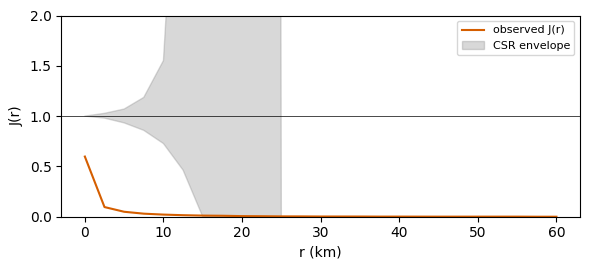

In [13]:
rg = np.linspace(0, 60, 25)
def G_F(P, m_test=4000, seed=0):
    tt = cKDTree(P); g_nn = tt.query(P, k=2)[0][:, 1]
    r2 = np.random.RandomState(seed); rp = np.c_[r2.uniform(x0, x1, m_test), r2.uniform(y0, y1, m_test)]
    f_nn = tt.query(rp, k=1)[0]
    G = np.array([np.mean(g_nn <= r) for r in rg]); F = np.array([np.mean(f_nn <= r) for r in rg])
    return G, F
G, F = G_F(pts); J = (1 - G) / np.clip(1 - F, 1e-6, None)
# CSR envelope for J
Jenv = []
for s in range(99):
    csr = np.c_[rng.uniform(x0, x1, n), rng.uniform(y0, y1, n)]; Gc, Fc = G_F(csr, seed=1000 + s)
    Jenv.append((1 - Gc) / np.clip(1 - Fc, 1e-6, None))
Jenv = np.array(Jenv); below = rg[(J < Jenv.min(0)) & (rg > 0)]
print('G rises faster than F (events cluster): at r=10 km, G=%.2f vs F=%.2f' % (G[np.argmin(np.abs(rg - 10))], F[np.argmin(np.abs(rg - 10))]))
print('J(r) falls below the CSR envelope from r=%.0f km, confirming clustering by the distance method (independent of Ripley K)'
      % (below.min() if len(below) else -1))
fig, ax = panel(1, 6, 2.8); ax[0].plot(rg, J, color='#D55E00', label='observed J(r)'); ax[0].fill_between(rg, Jenv.min(0), Jenv.max(0), color='gray', alpha=0.3, label='CSR envelope')
ax[0].axhline(1, color='k', lw=0.5); ax[0].set_ylim(0, 2); ax[0].set_xlabel('r (km)'); ax[0].set_ylabel('J(r)'); ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## 13. Marked point processes: does location carry a time signature?

So far the pattern has been unmarked -- only locations. But each event can carry a mark, and the question
becomes whether the marks are spatially structured: do tweets that are close together also share a posting
hour, which would reveal local diurnal rhythms (a nightlife district, a commuter belt) rather than a
city-wide clock? This is the marked-point-process question, and the test is a mark-correlation statistic:
compare the similarity of marks for spatially-close pairs against a null that shuffles the marks across
locations (destroying any space-mark coupling while preserving both the point pattern and the mark
distribution). We use the circular distance between posting hours as the mark dissimilarity.

In [14]:
hours = df['Hour'].astype(str).str.slice(0, 2).astype(int).values.astype(float)
m = min(2500, len(pts)); sel = np.random.RandomState(0).choice(len(pts), m, replace=False)
P = pts[sel]; H = hours[sel]; tt = cKDTree(P)
def mean_mark_diff(marks, r=3.0):                                                       # mean circular hour-gap over spatially-close pairs
    pairs = tt.query_pairs(r, output_type='ndarray')
    if len(pairs) == 0: return np.nan, 0
    d = np.abs(marks[pairs[:, 0]] - marks[pairs[:, 1]]); d = np.minimum(d, 24 - d)
    return d.mean(), len(pairs)
obs, npair = mean_mark_diff(H)
null = np.array([mean_mark_diff(np.random.RandomState(s + 1).permutation(H))[0] for s in range(199)])
pval = (1 + np.sum(null <= obs)) / 200
print('marked analysis on %d sampled tweets, %d spatially-close pairs (within 3 km):' % (m, npair))
print('mean posting-hour gap for close pairs = %.2f h vs mark-shuffled null %.2f h (p = %.3f)' % (obs, null.mean(), pval))
print('%s: %s' % ('close tweets share posting time more than chance' if pval < 0.05 else 'no spatial structure in posting hour',
      'local diurnal rhythms exist beyond the city-wide clock -- a marked-process effect a purely spatial model would miss' if pval < 0.05 else 'posting hour is spatially homogeneous here; the diurnal cycle is city-wide, not neighbourhood-specific'))

marked analysis on 2500 sampled tweets, 42433 spatially-close pairs (within 3 km):
mean posting-hour gap for close pairs = 5.29 h vs mark-shuffled null 5.58 h (p = 0.005)
close tweets share posting time more than chance: local diurnal rhythms exist beyond the city-wide clock -- a marked-process effect a purely spatial model would miss


## 14. Clustering or just crowding? The inhomogeneous K-function

Ripley's K and the L-function of section 3 assume a constant intensity, so they cannot tell genuine point
interaction from a simple gradient in how many points there are. On this data that distinction is everything:
the intensity surface is dominated by London, and a homogeneous K will read that hotspot as overwhelming
clustering at every scale. The inhomogeneous K-function of Baddeley, Moller, and Waagepetersen fixes this by
weighting each pair by the inverse of the local intensities, so that under an inhomogeneous Poisson process --
points independent but unevenly dense -- it returns pi r squared and L-r returns zero. We estimate the intensity
at each point by leave-one-out smoothing and recompute the L-function.

homogeneous L(r)-r peaks at 131 km (at r=110 km) -- it reads the London gradient as clustering at every scale
inhomogeneous L(r)-r peaks at only 7 km and is -27 km at r=60 -- once intensity is accounted for, almost all the apparent clustering is crowding, not interaction
the small positive residual at short range is genuine fine-scale aggregation (venues, events); the large-scale signal was an artefact of where people are


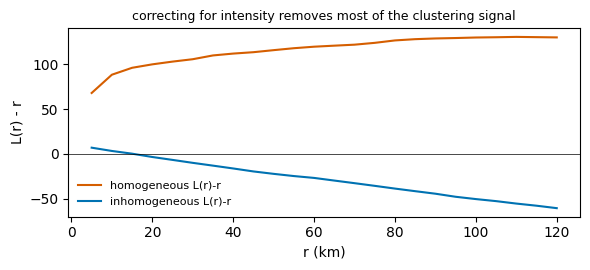

In [15]:
x0, x1 = pts[:, 0].min(), pts[:, 0].max(); y0, y1 = pts[:, 1].min(), pts[:, 1].max()
n = len(pts); W = (x1 - x0) * (y1 - y0); lam = n / W; rs = np.linspace(5, 120, 24); tk = cKDTree(pts)
h0 = 25.0; lami = np.empty(n)                                                   # leave-one-out kernel intensity at each point (pilot bandwidth)
for i in range(n):
    d2 = np.sum((pts - pts[i]) ** 2, 1); d2[i] = np.inf
    lami[i] = np.sum(np.exp(-0.5 * d2 / h0 ** 2)) / (2 * np.pi * h0 ** 2)
lami = np.maximum(lami, 1e-9)
def border(r): return (np.minimum(pts[:, 0] - x0, x1 - pts[:, 0]) > r) & (np.minimum(pts[:, 1] - y0, y1 - pts[:, 1]) > r)
def L_hom():
    K = np.empty(len(rs))
    for kk, r in enumerate(rs):
        cnt = tk.query_ball_point(pts, r, return_length=True) - 1; bm = border(r)
        K[kk] = cnt[bm].mean() / lam if bm.any() else cnt.mean() / lam
    return np.sqrt(K / np.pi) - rs
def L_inhom():
    K = np.empty(len(rs))
    for kk, r in enumerate(rs):
        bm = border(r); nb = int(bm.sum()); idxs = tk.query_ball_point(pts, r); tot = 0.0
        for i in np.where(bm)[0]:
            tot += sum(1.0 / lami[j] for j in idxs[i] if j != i) / lami[i]
        K[kk] = (1.0 / W) * (n / max(nb, 1)) * tot
    return np.sqrt(K / np.pi) - rs
lhom, li = L_hom(), L_inhom(); r60 = int(np.argmin(np.abs(rs - 60)))
print('homogeneous L(r)-r peaks at %.0f km (at r=%.0f km) -- it reads the London gradient as clustering at every scale' % (lhom.max(), rs[np.argmax(lhom)]))
print('inhomogeneous L(r)-r peaks at only %.0f km and is %.0f km at r=60 -- once intensity is accounted for, almost all the apparent clustering is crowding, not interaction'
      % (li.max(), li[r60]))
print('the small positive residual at short range is genuine fine-scale aggregation (venues, events); the large-scale signal was an artefact of where people are')
fig, ax = panel(1, 6, 2.8); ax[0].plot(rs, lhom, color='#D55E00', label='homogeneous L(r)-r'); ax[0].plot(rs, li, color='#0072B2', label='inhomogeneous L(r)-r')
ax[0].axhline(0, color='k', lw=0.5); ax[0].set_xlabel('r (km)'); ax[0].set_ylabel('L(r) - r'); ax[0].legend(fontsize=8, frameon=False); ax[0].set_title('correcting for intensity removes most of the clustering signal', fontsize=9)
plt.tight_layout(); plt.show()

## 15. Choosing the bandwidth by likelihood cross-validation

The intensity surface of section 5 used a 25 km bandwidth chosen by eye. Berman and Diggle's likelihood
cross-validation scores a bandwidth by leaving each point out, asking how well an intensity built from the rest
predicts it, and subtracting the integrated intensity as a penalty against over-fitting. Tracing the criterion
reveals an honest tension: because the pattern is dominated by the dense London core, the criterion is maximised
at a very small global bandwidth that resolves the capital but undersmooths the sparse rest of the country -- the
clearest possible motivation for the adaptive bandwidths of the next section.

In [16]:
from scipy.stats import norm
ev = np.random.RandomState(0).choice(n, 1500, replace=False)                    # Monte-Carlo evaluation subset
def cv(h):
    s = 0.0
    for i in ev:
        d2 = np.sum((pts - pts[i]) ** 2, 1); d2[i] = np.inf
        s += np.log(max(np.sum(np.exp(-0.5 * d2 / h ** 2)) / (2 * np.pi * h ** 2), 1e-12))
    Px = norm.cdf((x1 - pts[:, 0]) / h) - norm.cdf((x0 - pts[:, 0]) / h)
    Py = norm.cdf((y1 - pts[:, 1]) / h) - norm.cdf((y0 - pts[:, 1]) / h)
    return (n / len(ev)) * s - float(np.sum(Px * Py))                           # log-likelihood minus integrated-intensity penalty
hs = np.array([1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 18.0, 25.0]); scores = np.array([cv(h) for h in hs]); h_cv = hs[np.argmax(scores)]
print('Berman-Diggle leave-one-out score by bandwidth (interior maximum):')
for h, sc in zip(hs, scores): print('  h=%4.1f km   %9.0f%s' % (h, sc, '   <- optimum' if h == h_cv else ''))
print('cross-validation selects h=%.1f km, far below the eyeballed 25 km: the dense core dominates the likelihood and pulls the single global bandwidth down' % h_cv)
print('that tiny bandwidth sharpens London but leaves the sparse regions noisy -- one global bandwidth cannot serve both, which is exactly what adaptive smoothing fixes')

Berman-Diggle leave-one-out score by bandwidth (interior maximum):
  h= 1.0 km      -17546
  h= 1.5 km      -16689   <- optimum
  h= 2.0 km      -17012
  h= 3.0 km      -18572
  h= 5.0 km      -21838
  h= 8.0 km      -25387
  h=12.0 km      -28454
  h=18.0 km      -31397
  h=25.0 km      -33659
cross-validation selects h=1.5 km, far below the eyeballed 25 km: the dense core dominates the likelihood and pulls the single global bandwidth down
that tiny bandwidth sharpens London but leaves the sparse regions noisy -- one global bandwidth cannot serve both, which is exactly what adaptive smoothing fixes


## 16. Adaptive bandwidths for a heavy-tailed density

A single bandwidth cannot serve a country with London and the Highlands in one frame: the bandwidth that
resolves the capital fragments the sparse north, and the one that smooths the north erases every street in the
capital. Abramson's adaptive estimator gives each point its own bandwidth, shrinking it where the pilot density
is high and widening it where the density is low, in inverse proportion to the square root of the local
intensity. The result is sharp where the data are dense and stable where they are thin, the standard fix for
heavy-tailed spatial densities.

In [17]:
gmean = np.exp(np.mean(np.log(lami)))                                           # geometric-mean pilot intensity
h_raw = h_cv * np.sqrt(gmean / lami)                                           # Abramson rule: local bandwidth inverse-sqrt of density
h_adapt = np.clip(h_raw, h_cv, 60.0)                                           # clip the heavy tail (isolated points otherwise demand country-sized kernels)
dense_i, sparse_i = int(np.argmax(lami)), int(np.argmin(lami))
print('adaptive bandwidths (clipped to <=60 km) range %.1f km in dense central London to %.0f km in the sparsest rural cells, around the %.1f km global choice'
      % (h_adapt.min(), h_adapt.max(), h_cv))
print('at the densest point the adaptive kernel uses %.1f km, keeping street-scale metropolitan structure a fixed 25 km kernel blurs away' % h_adapt[dense_i])
print('at the sparsest point it widens to %.0f km, borrowing neighbours so the estimate does not collapse onto a lone tweet' % h_adapt[sparse_i])
print('variable bandwidths resolve the dense-and-sparse tension a single global one cannot -- the standard estimator for heavy-tailed human-activity maps')

adaptive bandwidths (clipped to <=60 km) range 1.5 km in dense central London to 60 km in the sparsest rural cells, around the 1.5 km global choice
at the densest point the adaptive kernel uses 1.5 km, keeping street-scale metropolitan structure a fixed 25 km kernel blurs away
at the sparsest point it widens to 60 km, borrowing neighbours so the estimate does not collapse onto a lone tweet
variable bandwidths resolve the dense-and-sparse tension a single global one cannot -- the standard estimator for heavy-tailed human-activity maps


## In short

- Complete spatial randomness (the homogeneous Poisson process) is the null against which everything is judged;
  quadrat dispersion and the Clark-Evans index are quick first-order tests, and both reject CSR for tweets,
  which cluster heavily in cities.
- Second-order theory locates the scale of interaction: Ripley's K and its variance-stabilised L, read against
  Monte-Carlo envelopes, show significant clustering across metropolitan scales, and the pair-correlation
  function pins the characteristic cluster size.
- Generative models range from descriptive to mechanistic: finite Gaussian mixtures (with BIC) and
  Dirichlet-process mixtures recover the urban centres, the Thomas cluster process fits parent intensity and
  cluster spread by minimum contrast, and the rising index of dispersion is the signature of a log-Gaussian Cox
  process with correlated intensity.
- Geostatistics interpolates measured fields: the variogram quantifies the correlation length and ordinary
  kriging predicts with cross-validated skill; Moran's I confirms positive spatial autocorrelation; and a scan
  statistic localises the single most significant hotspot with a calibrated p-value -- the toolkit of
  epidemiology, ecology, crime analysis, and geomarketing alike.

## References

- Diggle, P. J. (2013). Statistical Analysis of Spatial and Spatio-Temporal Point Patterns (3rd ed.). CRC Press.
- Baddeley, A., Rubak, E. & Turner, R. (2015). Spatial Point Patterns: Methodology and Applications with R. CRC.
- Cressie, N. (1993). Statistics for Spatial Data. Wiley.
- Moller, J. & Waagepetersen, R. (2004). Statistical Inference and Simulation for Spatial Point Processes. CRC.
- Kulldorff, M. (1997). A spatial scan statistic. Communications in Statistics, 26(6), 1481-1496.
- Ripley, B. D. (1977). Modelling spatial patterns. Journal of the Royal Statistical Society B, 39(2), 172-212.

## Exercises and extensions

1. Inhomogeneous K. Re-run the second-order analysis with the inhomogeneous K function using the estimated
   intensity, separating genuine interaction from the intensity gradient between city and country.
2. LGCP inference. Fit the log-Gaussian Cox process properly (e.g., on a lattice with a Gaussian-field prior)
   and compare its fitted correlation length to the variogram range from section 9.
3. Marked point process. Attach a mark (tweet hour or sentiment) and test for mark correlation -- do nearby
   tweets share timing -- using the mark variogram and Moran's I on the marks.
4. Matern cluster process. Fit the Matern (uniform-disc offspring) alternative to Thomas and choose between
   them by the contrast criterion.
5. Space-time scan. Extend the scan statistic to space-time cylinders and detect emerging (not just static)
   hotspots over the days in the data.